# Baseline Model Training
## AI Customer Sentiment Analytics Platform

**Models:** Logistic Regression, SVM, Random Forest  
**Features:** TF-IDF (10,000 features, unigrams + bigrams)  
**Target:** airline_sentiment (negative / neutral / positive)  
**Primary Metric:** Weighted F1-Score

In [1]:
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

print("✅ All imports successful")

✅ All imports successful


In [2]:
DATA_PROCESSED = "../../ml/data/processed"
MODELS_BASELINE = "../../ml/models/baseline"

# Load train/test split
X_train, X_test, y_train, y_test = joblib.load(
    f"{DATA_PROCESSED}/train_test_split.pkl"
)

# Load label encoder
label_encoder = joblib.load(f"{MODELS_BASELINE}/label_encoder.pkl")
class_names = label_encoder.classes_

print("✅ Artifacts loaded successfully")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Classes       : {class_names}")

✅ Artifacts loaded successfully
X_train shape : (10831, 10000)
X_test shape  : (2708, 10000)
Classes       : ['negative' 'neutral' 'positive']


In [3]:
def evaluate_model(
    model,
    X_test: np.ndarray,
    y_test: np.ndarray,
    class_names: list,
    model_name: str
) -> dict:
    """
    Evaluate a trained classifier and return metrics.

    Args:
        model: Trained sklearn classifier.
        X_test: Test feature matrix.
        y_test: True labels.
        class_names: List of class name strings.
        model_name: Name for display purposes.

    Returns:
        Dictionary containing all evaluation metrics.
    """
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    f1_macro = f1_score(y_test, y_pred, average="macro")

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy         : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"F1 Weighted      : {f1_weighted:.4f}")
    print(f"F1 Macro         : {f1_macro:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    return {
        "name": model_name,
        "model": model,
        "accuracy": accuracy,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        "y_pred": y_pred
    }

print("✅ Evaluation function defined")

✅ Evaluation function defined


In [4]:
results = []

# 1. Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    C=1.0
)
lr.fit(X_train, y_train)
results.append(evaluate_model(lr, X_test, y_test, class_names, "Logistic Regression"))

# 2. Linear SVM
print("\nTraining Linear SVM...")
svm = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=2000,
    C=1.0
)
svm.fit(X_train, y_train)
results.append(evaluate_model(svm, X_test, y_test, class_names, "Linear SVM"))

# 3. Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_test, y_test, class_names, "Random Forest"))

Training Logistic Regression...

Model: Logistic Regression
Accuracy         : 0.7467 (74.67%)
F1 Weighted      : 0.7554
F1 Macro         : 0.6855

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.79      0.83      1785
     neutral       0.51      0.62      0.56       524
    positive       0.60      0.74      0.67       399

    accuracy                           0.75      2708
   macro avg       0.67      0.72      0.69      2708
weighted avg       0.77      0.75      0.76      2708


Training Linear SVM...

Model: Linear SVM
Accuracy         : 0.7618 (76.18%)
F1 Weighted      : 0.7605
F1 Macro         : 0.6783

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      1785
     neutral       0.53      0.49      0.51       524
    positive       0.65      0.69      0.67       399

    accuracy                           0.76      2708
   macro avg       0.6

In [5]:
comparison_df = pd.DataFrame([
    {
        "Model": r["name"],
        "Accuracy": f"{r['accuracy']*100:.2f}%",
        "F1 Weighted": f"{r['f1_weighted']:.4f}",
        "F1 Macro": f"{r['f1_macro']:.4f}"
    }
    for r in results
])

print("=== Model Comparison ===")
print(comparison_df.to_string(index=False))

# Find best model by weighted F1
best = max(results, key=lambda x: x["f1_weighted"])
print(f"\n🏆 Best model: {best['name']} (F1 Weighted: {best['f1_weighted']:.4f})")

=== Model Comparison ===
              Model Accuracy F1 Weighted F1 Macro
Logistic Regression   74.67%      0.7554   0.6855
         Linear SVM   76.18%      0.7605   0.6783
      Random Forest   75.85%      0.7399   0.6384

🏆 Best model: Linear SVM (F1 Weighted: 0.7605)


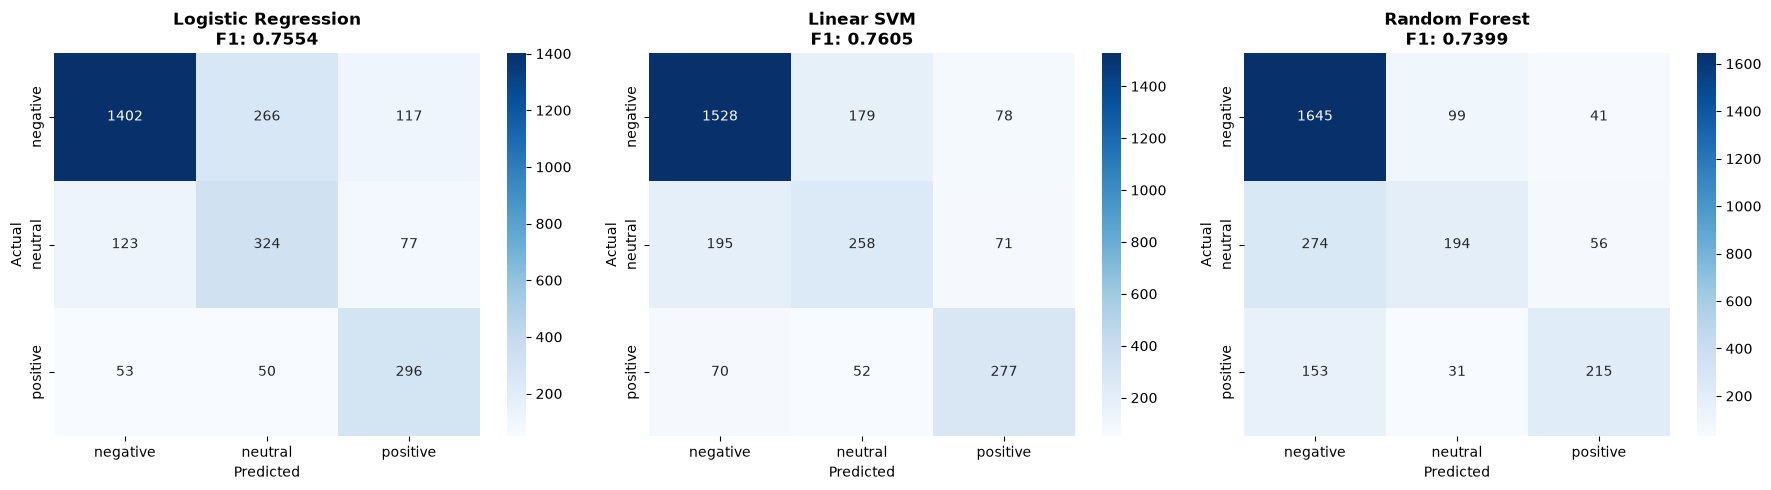

✅ Confusion matrices saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, result in enumerate(results):
    cm = confusion_matrix(y_test, result["y_pred"])
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f"{result['name']}\nF1: {result['f1_weighted']:.4f}", 
                         fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../../ml/reports/baseline_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrices saved")

In [7]:
best_model = best["model"]
best_name = best["name"]

# Save best model
joblib.dump(best_model, f"{MODELS_BASELINE}/best_baseline_model.pkl")

# Save model metadata
metadata = {
    "model_name": best_name,
    "f1_weighted": best["f1_weighted"],
    "f1_macro": best["f1_macro"],
    "accuracy": best["accuracy"],
    "classes": list(class_names),
    "features": 10000,
    "training_samples": X_train.shape[0],
    "test_samples": X_test.shape[0]
}

joblib.dump(metadata, f"{MODELS_BASELINE}/model_metadata.pkl")

print(f"✅ Best model saved: {best_name}")
print(f"   Path: {MODELS_BASELINE}/best_baseline_model.pkl")
print(f"\nModel Metadata:")
for key, value in metadata.items():
    if key != "model_name":
        print(f"  {key}: {value}")

✅ Best model saved: Linear SVM
   Path: ../../ml/models/baseline/best_baseline_model.pkl

Model Metadata:
  f1_weighted: 0.7604993457084023
  f1_macro: 0.6783338922936784
  accuracy: 0.7618168389955687
  classes: ['negative', 'neutral', 'positive']
  features: 10000
  training_samples: 10831
  test_samples: 2708


## Baseline Model Summary

### Results
| Model | Accuracy | F1 Weighted | F1 Macro |
|---|---|---|---|
| Logistic Regression | 74.67% | 0.7554 | 0.6855 |
| Linear SVM | 76.18% | 0.7605 | 0.6783 |
| Random Forest | 75.85% | 0.7399 | 0.6384 |

### Winner: Linear SVM (F1 Weighted: 0.7605)

### Key Findings
- Negative class performs best (F1: 0.85) — largest training set
- Neutral class is hardest (F1: 0.51) — genuinely ambiguous tweets
- Positive class limited by small training size (F1: 0.67)
- class_weight="balanced" critical for handling imbalance

### Next Step
Build advanced transformer model (BERT/RoBERTa) and compare
against this 0.7605 F1 weighted baseline.